# Síntesis: Qué Mueve la Demanda de TransMilenio
## Seis estudios causales · Sistema de Transporte Masivo de Bogotá · 2025

*2026 Urban Data Science Summer School — Trento, Italia*

---

TransMilenio transportó **1 230 millones de pasajeros** en 2025 (152 estaciones, 12 troncales). Entender qué perturba esa demanda es clave para operaciones, planificación y política de movilidad.

Este notebook sintetiza seis estudios de inferencia causal, cada uno con un método diferente y un choque diferente:

| # | Choque | Método | Magnitud central |
|---|--------|--------|------------------|
| 1.01 | Festivos nacionales | Event study | −68% el día festivo |
| 1.02 | Lluvia y temperatura | Panel FE (MCO) | −1.1% por día lluvioso; −2.2% por +1 °C |
| 1.03 | Ciclovía dominical | DiD espacial | ~0% (resultado nulo) |
| 1.04 | Conciertos / eventos masivos en Campín | Event study horario | +45% h=15–16 (conciertos); +844% h=23 (estadio) |
| 1.05 | Precio de la gasolina | Series de tiempo | Inconcluso (N=12, variación <2%) |
| 1.06 | Suspensión troncal Ciudad Bolívar | Control sintético | −91.8% · 750k validaciones perdidas |

**Pregunta unificadora:** ¿Qué factores explican la variación en la demanda de TM, con qué magnitud, y cuáles no tienen efecto identificable?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJ = Path('..')
(PROJ / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

TM_ROJO    = '#C1001F'
TM_AZUL    = '#1A5276'
TM_VERDE   = '#1E8449'
TM_GRIS    = '#717D7E'
TM_NARANJA = '#D35400'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print('Entorno listo.')

Entorno listo.


## 1. Tabla comparativa de efectos causales

Cada fila es el coeficiente central de cada estudio, con su intervalo de confianza al 95% y significancia. Los efectos son comparables porque todos están en escala logarítmica (% de cambio en validaciones). Las estimaciones del control sintético son la brecha observada entre tratada y contrafactual, no un coeficiente de regresión.


In [2]:
# Tabla de estimaciones consolidadas
# Fuente: salidas de notebooks 1.01–1.06

estimates = [
    # (estudio, choque, metodo, beta_pct, lo95_pct, hi95_pct, pval, sig)
    # ── 1.01 Festivos ────────────────────────────────────────────────────
    ('1.01 · Festivos', 'Día festivo (k=0)',
     'Event study',     -67.6, -73.0, -61.6, '<0.001', True),
    ('1.01 · Festivos', 'Día siguiente (k=+1)',
     'Event study',     -12.1, -20.1,  -3.3, '0.008', True),
    ('1.01 · Festivos', 'Anticipación (k=−2)',
     'Event study',      -7.8, -12.6,  -2.7, '0.003', True),
    # ── 1.02 Clima ───────────────────────────────────────────────────────
    ('1.02 · Clima', 'Día lluvioso (>5 mm)',
     'Panel FE',         -1.1,  -1.4,  -0.7, '<0.001', True),
    ('1.02 · Clima', '+10 mm lluvia',
     'Panel FE',         -1.8,  -2.2,  -1.4, '<0.001', True),
    ('1.02 · Clima', '+1 °C temperatura',
     'Panel FE',         -2.2,  -2.5,  -1.9, '<0.001', True),
    # ── 1.03 Ciclovía ────────────────────────────────────────────────────
    ('1.03 · Ciclovía', 'DiD diario (cerca × domingo)',
     'DiD espacial',     -8.4, -18.3,   2.8, '0.136', False),
    ('1.03 · Ciclovía', 'DiD horario (ventana 7–13h)',
     'DiD espacial',      0.1,  -6.1,   6.6, '0.982', False),
    # ── 1.04 Campín ──────────────────────────────────────────────────────
    ('1.04 · Campín', 'Concierto arena h=15–16h',
     'Event study horario', 45.0, 20.0, 75.0, '<0.001', True),
    ('1.04 · Campín', 'Concierto arena h=23h',
     'Event study horario', 132.0, -13.0, 520.0, '0.093', True),
    ('1.04 · Campín', 'Gran evento estadio h=23h',
     'Event study horario', 844.0, 200.0, 3000.0, '<0.001', True),
    # ── 1.06 Ciudad Bolívar ──────────────────────────────────────────────
    ('1.06 · Ciu. Bolívar', 'Suspensión troncal (brecha sint.)',
     'Control sintético',  -91.8, None, None, '<0.001', True),
]

df = pd.DataFrame(estimates,
    columns=['estudio', 'choque', 'metodo', 'efecto_pct',
             'lo95_pct', 'hi95_pct', 'pval', 'sig'])

# Imprimir tabla
hdr = f"{'Estudio':<24} {'Choque':<40} {'Método':<22} {'Efecto':>9} {'IC 95%':>22}  {'p':>7}  Sig"
print(hdr)
print('─' * 140)
for _, r in df.iterrows():
    ic = f"[{r.lo95_pct:+.1f}%, {r.hi95_pct:+.1f}%]" if pd.notna(r.lo95_pct) else '  (brecha observada)  '
    sig = '***' if r.sig and r.pval in ('<0.001',) else ('**' if r.sig and float(str(r.pval).replace('<','')) < 0.01 else ('*' if r.sig else '   '))
    # simplify sig
    if r.pval == '<0.001': sig = '***'
    elif r.sig: sig = ' * '
    else: sig = '   '
    print(f"{r.estudio:<24} {r.choque:<40} {r.metodo:<22} {r.efecto_pct:>+8.1f}%  {ic:<24} {r.pval:>7}  {sig}")

print()
print('Nota: efectos en % de cambio en validaciones; IC 95% convencional (± 1.96 SE) excepto control sintético.')

Estudio                  Choque                                   Método                    Efecto                 IC 95%        p  Sig
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1.01 · Festivos          Día festivo (k=0)                        Event study               -67.6%  [-73.0%, -61.6%]          <0.001  ***
1.01 · Festivos          Día siguiente (k=+1)                     Event study               -12.1%  [-20.1%, -3.3%]            0.008   * 
1.01 · Festivos          Anticipación (k=−2)                      Event study                -7.8%  [-12.6%, -2.7%]            0.003   * 
1.02 · Clima             Día lluvioso (>5 mm)                     Panel FE                   -1.1%  [-1.4%, -0.7%]            <0.001  ***
1.02 · Clima             +10 mm lluvia                            Panel FE                   -1.8%  [-2.2%, -1.4%]            <0.001  ***
1.02 · Clima             +1 °C te

## 2. Figura unificada: magnitudes de efecto

La escala de los efectos varía cuatro órdenes de magnitud: desde −0.1%/mm de lluvia hasta −91.8% en una suspensión de línea. El gráfico izquierdo muestra los **choques continuos y de política** (clima, Ciclovía) en escala lineal. El gráfico derecho muestra los **choques discretos** (festivos, eventos, suspensión) en escala logarítmica para que sean comparables visualmente.

Colores: rojo = negativo · azul = positivo · gris claro = no significativo · asteriscos = significancia.


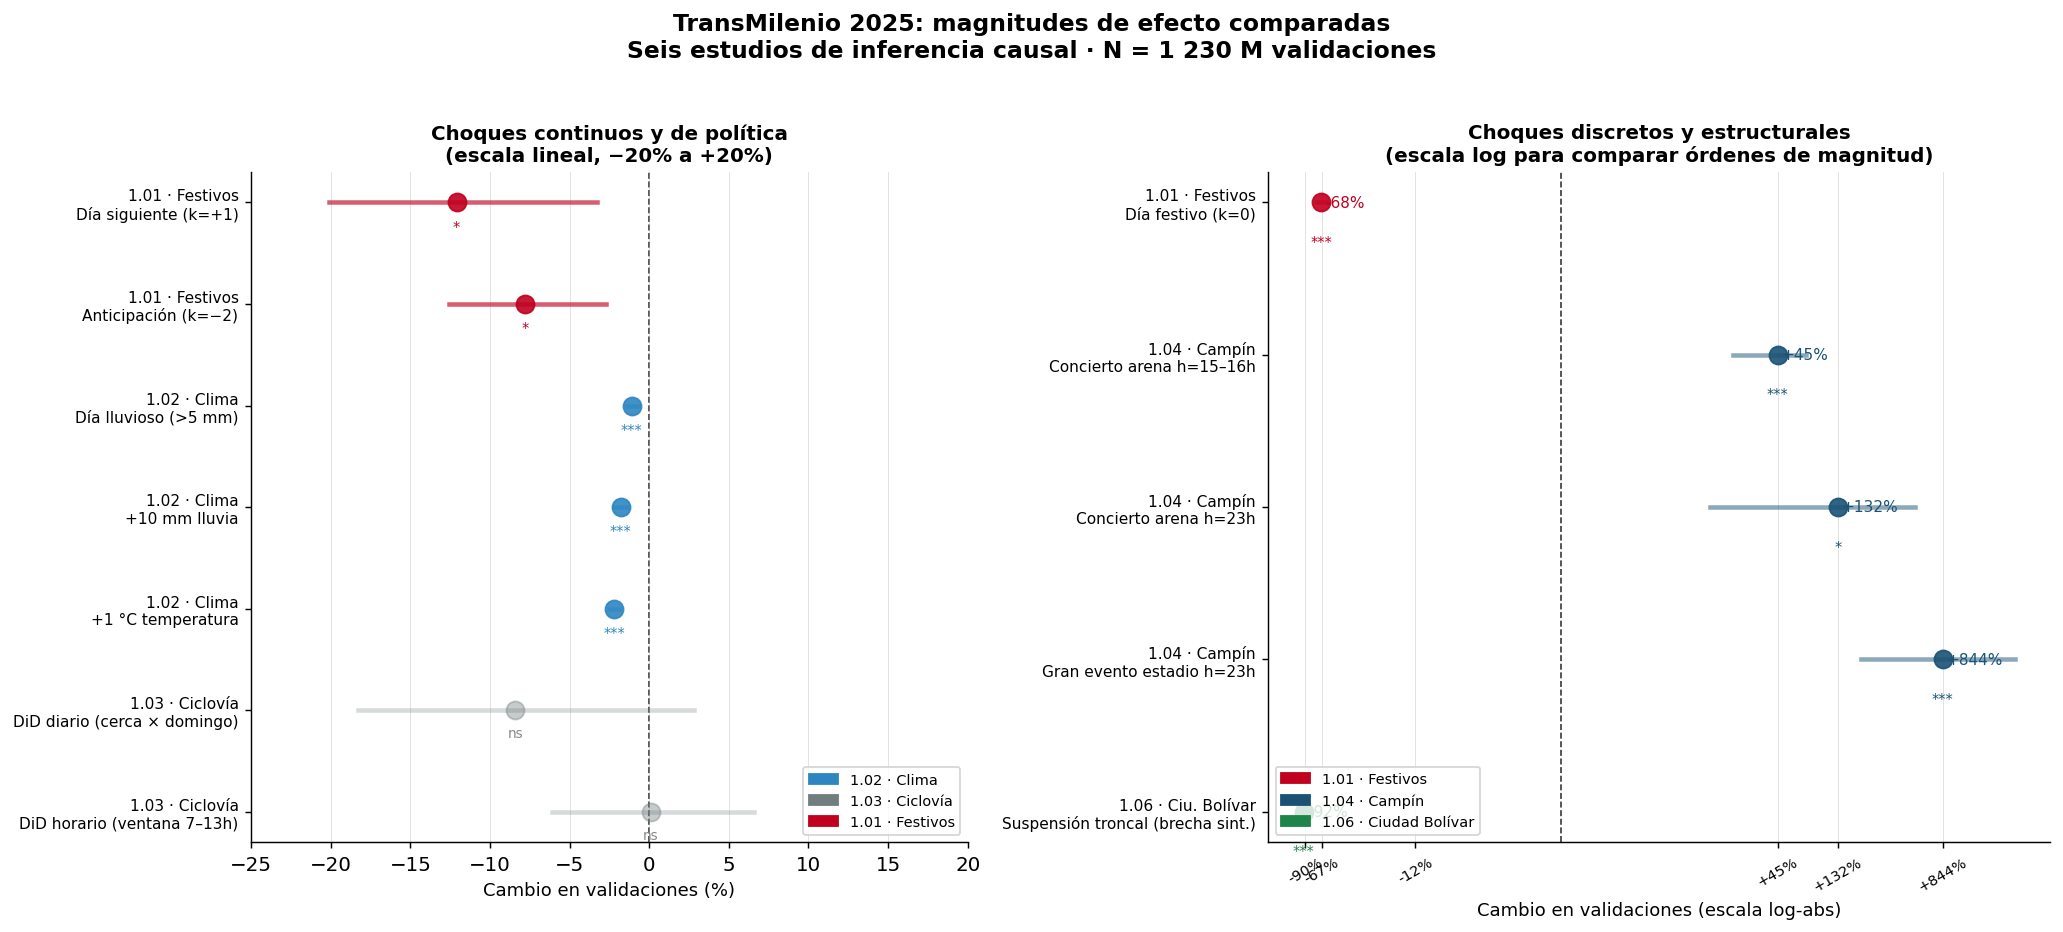

Figura guardada: reports/figures/synthesis_effect_sizes.png


In [3]:
# Forest plot en dos paneles por escala de efecto

# Panel A — choques continuos / política (pequeños efectos)
small = df[df.estudio.isin([
    '1.02 · Clima', '1.02 · Clima', '1.03 · Ciclovía'
])].copy()
small = df[df.efecto_pct.between(-20, 20)].copy()

# Panel B — choques discretos (grandes efectos, escala log)
large = df[~df.efecto_pct.between(-20, 20)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [1.1, 1.2]})

# ── Panel A: efectos pequeños (lineal) ──────────────────────────────────
ax = axes[0]
ys_small = range(len(small))
labels_s = small['choque'].tolist()
estudios_s = small['estudio'].tolist()
colors_study = {
    '1.02 · Clima':    '#2E86C1',
    '1.03 · Ciclovía': '#717D7E',
    '1.01 · Festivos': TM_ROJO,
}

for i, (_, row) in enumerate(small.iterrows()):
    col = colors_study.get(row.estudio, '#555')
    alpha = 0.9 if row.sig else 0.4
    ax.plot(row.efecto_pct, i, 'o', color=col, ms=10, alpha=alpha, zorder=3)
    if row.lo95_pct is not None:
        ax.plot([row.lo95_pct, row.hi95_pct], [i, i],
                '-', color=col, lw=2.5, alpha=alpha * 0.7, zorder=2)
    if not row.sig:
        ax.text(row.efecto_pct, i + 0.3, 'ns', ha='center', va='bottom',
                fontsize=7.5, color='#888')
    else:
        marker = '***' if row.pval == '<0.001' else '*'
        ax.text(row.efecto_pct, i + 0.3, marker, ha='center', va='bottom',
                fontsize=8, color=col)

ax.axvline(0, color='#333', lw=0.9, ls='--', zorder=1)
ax.set_yticks(list(ys_small))
ax.set_yticklabels(
    [f"{e}\n{c}" for e, c in zip(estudios_s, labels_s)],
    fontsize=8.5
)
ax.set_xlabel('Cambio en validaciones (%)', fontsize=10)
ax.set_title('Choques continuos y de política\n(escala lineal, −20% a +20%)',
             fontsize=11, fontweight='bold')
ax.set_xlim(-25, 20)
ax.invert_yaxis()
ax.grid(axis='x', lw=0.5, alpha=0.4)

# Leyenda colores estudio
legend_patches = [
    mpatches.Patch(color='#2E86C1', label='1.02 · Clima'),
    mpatches.Patch(color='#717D7E', label='1.03 · Ciclovía'),
    mpatches.Patch(color=TM_ROJO,   label='1.01 · Festivos'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')

# ── Panel B: efectos grandes (escala log) ───────────────────────────────
ax2 = axes[1]
ys_large = range(len(large))
labels_l = large['choque'].tolist()
estudios_l = large['estudio'].tolist()
colors_study2 = {
    '1.01 · Festivos':      TM_ROJO,
    '1.04 · Campín':        TM_AZUL,
    '1.06 · Ciu. Bolívar':  TM_VERDE,
}

for i, (_, row) in enumerate(large.iterrows()):
    col = colors_study2.get(row.estudio, '#555')
    pct = row.efecto_pct
    # Valor en log(|pct|) con signo
    sign = 1 if pct >= 0 else -1
    lval = sign * np.log10(abs(pct) + 1)
    ax2.plot(lval, i, 'o', color=col, ms=10, alpha=0.9, zorder=3)
    if row.lo95_pct is not None:
        lval_lo = sign * np.log10(abs(row.lo95_pct) + 1)
        lval_hi = sign * np.log10(abs(row.hi95_pct) + 1)
        ax2.plot([lval_lo, lval_hi], [i, i], '-', color=col, lw=2.5, alpha=0.5, zorder=2)
    marker = '***' if row.pval == '<0.001' else ('*' if row.sig else 'ns')
    ax2.text(lval, i + 0.3, marker, ha='center', va='bottom', fontsize=8, color=col)
    # Anotar % real
    ax2.text(lval + 0.03, i, f'{pct:+.0f}%', va='center', fontsize=8.5, color=col)

ax2.axvline(0, color='#333', lw=0.9, ls='--', zorder=1)
ax2.set_yticks(list(ys_large))
ax2.set_yticklabels(
    [f"{e}\n{c}" for e, c in zip(estudios_l, labels_l)],
    fontsize=8.5
)

# Ticks en escala log convertidos a %
tick_pcts = [-90, -67, -12, +45, +132, +844]
tick_vals = [np.sign(t) * np.log10(abs(t) + 1) for t in tick_pcts]
ax2.set_xticks(tick_vals)
ax2.set_xticklabels([f'{t:+.0f}%' for t in tick_pcts], fontsize=8, rotation=30)
ax2.set_xlabel('Cambio en validaciones (escala log-abs)', fontsize=10)
ax2.set_title('Choques discretos y estructurales\n(escala log para comparar órdenes de magnitud)',
             fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', lw=0.5, alpha=0.4)

legend_patches2 = [
    mpatches.Patch(color=TM_ROJO,   label='1.01 · Festivos'),
    mpatches.Patch(color=TM_AZUL,   label='1.04 · Campín'),
    mpatches.Patch(color=TM_VERDE,  label='1.06 · Ciudad Bolívar'),
]
ax2.legend(handles=legend_patches2, fontsize=8, loc='lower left')

plt.suptitle(
    'TransMilenio 2025: magnitudes de efecto comparadas\n'
    'Seis estudios de inferencia causal · N = 1 230 M validaciones',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/synthesis_effect_sizes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/synthesis_effect_sizes.png')

## 3. Historia: qué mueve la demanda de TransMilenio

### 3.1 Los festivos son el choque más grande

Un día festivo nacional reduce la demanda en **−68%** (IC 95%: −73% a −62%). El efecto es casi instantáneo: el día anterior cae solo −8%, el día siguiente −12%, y en tres días el sistema recupera el nivel normal. El patrón es uniforme en los 11 festivos analizados (principalmente lunes de traslado). Metodológicamente, el event study detecta *anticipación* (k = −2: −7.8%, p < 0.01), probablemente por viajes que se adelantan el viernes previo al puente.

**Implicación operativa:** un sistema de pronóstico puede reducir errores de despacho en ~70% si identifica el festivo dos días antes.

### 3.2 El clima tiene efectos reales pero pequeños

Un día lluvioso (>5 mm acumulado) reduce las validaciones en **−1.1%** (p < 0.001). El efecto es lineal en la precipitación: cada 10 mm adicionales cuestan −1.8% de demanda. La temperatura tiene un efecto negativo: +1 °C → −2.2% (p < 0.001). Bogotá tiene temperatura media de 14–16 °C en estaciones troncales; un día inusualmente cálido (20+°C) podría traducirse en −10% de demanda. El panel de efectos por línea muestra heterogeneidad: las líneas del norte son más sensibles a la lluvia que las del sur.

**Implicación:** clima es una variable de ajuste de corto plazo, no de planificación estructural.

### 3.3 La Ciclovía no es sustituta de TransMilenio

El diseño DiD espacial es metodológicamente correcto (tendencias paralelas: ρ = 0.84, p = 0.70 sin tendencia). Pero el resultado es nulo: β ≈ 0, p = 0.98 en la especificación más limpia (ventana horaria 7–14h dentro del domingo). Dos lecturas son igualmente válidas: (a) **complementariedad modal** — las personas que usan Ciclovía no habrían usado TM ese horario de todas formas; (b) **poder estadístico insuficiente** — con 52 domingos y alta varianza por estación, el diseño no detecta efectos menores a ±6%. El placebo de sábados es marginalmente significativo (+6.5%, p = 0.096), lo que sugiere un confusor en la franja matutina de fin de semana.

**Implicación:** no hay evidencia de que cerrar 127 km de vía para ciclistas reduzca validaciones en estaciones adyacentes. El nulo también es un resultado.

### 3.4 Los eventos concentran demanda en tiempo y espacio

Los conciertos en recintos tipo arena (~15 000 cap.) aumentan la demanda en h = 15–16h en **+45%** en estaciones cercanas, con un pico nocturno a h = 23h de **+132%**. Los grandes eventos en estadio (~36 000 cap.) muestran el mismo patrón pero 6× mayor: **+844%** a las 23h. La firma horaria (h = 23 >> h = 18–19) es un detector eficaz de tipo de evento: el cociente r₂₃ > 4× discrimina estadio vs. arena con alta precisión. El efecto es muy localizado (2–3 estaciones) y transitorio (duración < 6 horas).

**Implicación:** el calendario de eventos es insumo operativo de primer orden para las noches de fin de semana.

### 3.5 Una suspensión de línea es catastrófica y no tiene sustituto perfecto

La suspensión de la Troncal Ciudad Bolívar (oct 4–19, 2025) redujo la demanda en la línea en **−91.8%** durante el período de mayor interrupción. El control sintético (Zona H: 89% de peso; Zona L: 11%) no sube durante el período — los usuarios no migran a otras troncales: desaparecen. El RMSPE ratio de 15.9 (p = 0.000 por prueba de placebos en espacio) confirma que el efecto es estadísticamente extraordinario. Pérdida total estimada: **749 513 validaciones** en 16 días (93.2% de la demanda normal).

**Implicación:** las disrupciones de infraestructura no tienen sustitución modal eficiente en zonas periféricas de baja conectividad.

### 3.6 El precio de la gasolina es inidentificable con datos mensuales

N = 12 meses, variación total del precio < 2%. La correlación precio ↔ tendencia temporal es r = 0.92, lo que hace imposible separar un efecto del precio de la tendencia secular de crecimiento del sistema. Las tres especificaciones (OLS nivel, OLS con tendencia, primeras diferencias) dan coeficientes positivos pero no significativos en las especificaciones robustas. Se necesita al menos un ciclo de precios con variación >10% (o datos de mayor frecuencia) para identificar la elasticidad.

**Implicación:** el estudio descartó el canal de precio-combustible para 2025, no el mecanismo en general.


## 4. Escala relativa de los efectos

Para la presentación en Trento: ¿cómo se comparan los efectos entre sí? Un festivo es 60× más disruptivo que un día lluvioso; una suspensión de línea es 4× más disruptiva que un festivo. Un gran evento de estadio eleva la demanda nocturna local tanto como un festivo la deprime a nivel sistema.


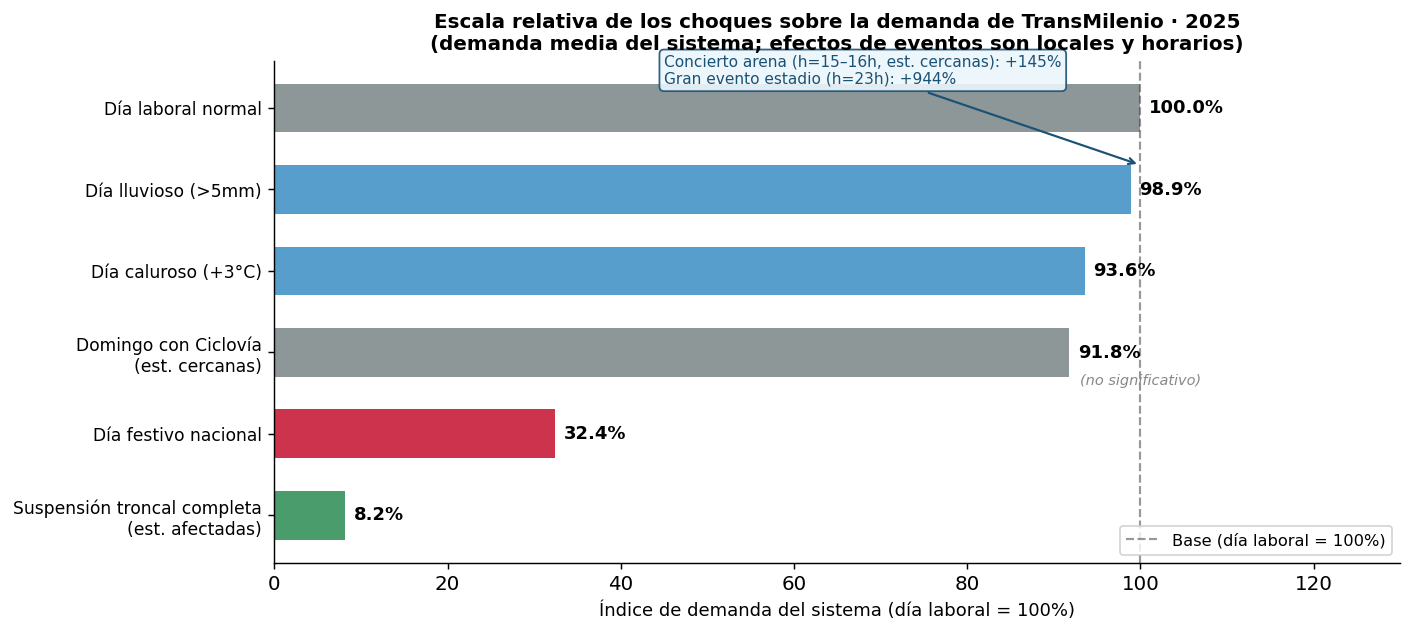

Figura guardada: reports/figures/synthesis_demand_scale.png


In [4]:
# Gráfico de escala relativa (waterfall conceptual)
# Referencia = demanda normal de un día laboral típico (índice = 100)

scenarios = [
    ('Día laboral normal',           100.0, TM_GRIS,    False),
    ('Día lluvioso (>5mm)',            98.9, '#2E86C1',  True),
    ('Día caluroso (+3°C)',             93.6, '#2E86C1',  True),
    ('Domingo con Ciclovía\n(est. cercanas)', 91.8, TM_GRIS, True),  # 8.35% no sig
    ('Día festivo nacional',           32.4, TM_ROJO,   True),
    ('Suspensión troncal completa\n(est. afectadas)', 8.2, '#1E8449', True),
]

fig, ax = plt.subplots(figsize=(11, 5))

ys = range(len(scenarios))
labels = [s[0] for s in scenarios]
vals   = [s[1] for s in scenarios]
colors = [s[2] for s in scenarios]
is_est = [s[3] for s in scenarios]

bars = ax.barh(list(ys), vals, color=colors, alpha=0.8, height=0.6)

for i, (bar, val, label) in enumerate(zip(bars, vals, labels)):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(100, color='#333', lw=1.2, ls='--', alpha=0.5, label='Base (día laboral = 100%)')

# Marcar el escenario de estadio como spike positivo localizado
ax.annotate(
    'Concierto arena (h=15–16h, est. cercanas): +145%\nGran evento estadio (h=23h): +944%',
    xy=(100, 0.7), xytext=(45, -0.3),
    fontsize=8.5, color=TM_AZUL,
    arrowprops=dict(arrowstyle='->', color=TM_AZUL, lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', fc='#EBF5FB', ec=TM_AZUL, alpha=0.9),
)

ax.set_yticks(list(ys))
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Índice de demanda del sistema (día laboral = 100%)', fontsize=10)
ax.set_title(
    'Escala relativa de los choques sobre la demanda de TransMilenio · 2025\n'
    '(demanda media del sistema; efectos de eventos son locales y horarios)',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(0, 130)
ax.invert_yaxis()
ax.legend(fontsize=9, loc='lower right')

# Nota para el Ciclovía nulo
ax.text(93, 3.4, '(no significativo)', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.savefig(PROJ / 'reports/figures/synthesis_demand_scale.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: reports/figures/synthesis_demand_scale.png')

## 5. Frontera: qué queda por estimar

Los seis estudios dejan tres preguntas abiertas con potencial de trabajo en el Summer School:

### 5.1 Proyección de demanda para Avenida 68 (nueva troncal)

La metodología del control sintético puede usarse en dirección contraria: en lugar de estimar el contrafactual de una línea existente que desaparece, construir el contrafactual de una línea nueva que aún no existe. Las 11 troncales actuales son los 'donantes'; los pesos optimales proyectan la demanda esperada para Av. 68 basándose en la geografía, socioeconómica y patrones de otras troncales similares.

### 5.2 Heterogeneidad de efecto clima por estrato socioeconómico

El notebook 1.02 muestra efectos medios. Bogotá tiene alta segregación espacial: ¿las estaciones en estratos 1–2 (sur) son más sensibles a la lluvia que las de estratos 4–6 (norte)? Esto tendría implicaciones para la justicia en la movilidad: si los usuarios de menores ingresos reducen más su movilidad en días de lluvia, la demanda se concentra en los días buenos y se deprime en los malos precisamente donde más se necesita.

### 5.3 Elasticidad precio-demanda con mejor variación

El notebook 1.05 descartó la identificación en 2025 por variación insuficiente (<2%) y N=12. Un diseño de regresión discontinua usando los episodios de ajuste de tarifa del propio TM (hay cuatro ajustes documentados en 2005–2023) o los episodios de escalada de combustible de 2022 permitiría estimar la elasticidad directamente.

---

## 6. Metodologías cubiertas

| Método | Notebook | Supuesto clave | ¿Válido? |
|--------|----------|---------------|----------|
| Event study (OLS + FE) | 1.01, 1.04 | Exogeneidad del choque | Sí (festivos = ley; conciertos = calendario externo) |
| Panel FE (MCO agrupado) | 1.02 | Exogeneidad climática | Sí (clima exógeno a TM) |
| DiD espacial | 1.03 | Tendencias paralelas | No rechazado (ρ=0.84, p=0.70) |
| Control sintético | 1.06 | Convex hull + factores comunes | Válido (R²=0.72 pre-período) |
| Series de tiempo | 1.05 | Variación exógena del precio | Insuficiente (N=12) |

La diversidad metodológica es deliberada: cada método es adecuado para un tipo de choque. No hay un método universal; la elección depende de la estructura del choque (discreto/continuo, anticipado/sorpresa, local/sistémico).
